In [1]:
NEW_RANK = 1
# NEW_RANK = 16 # 32 or higher crashes the kernel or takes too long.

In [2]:
import torch
from pathlib import Path
from tqdm.auto import tqdm

from src.utils.lora_vector_utils import LoRaVector, LoRaVectorCollection

REPO = "persona-shattering-lasr/monorepo"

# Persisted artefact root for this notebook. Relative to the notebook's cwd
# (scripts_dev/flatten_loras/), matching how scratch/lora_cache resolves.
DATA_DIR = Path("data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

OCEAN_TRAITS = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
]
DIRECTIONS = [
    ("amplifier", "amplifying", "+"),
    ("suppressor", "suppressing", "-"),
]

# (display_name, subfolder) pairs
# Multiple versions of the same trait get a version suffix in the display name
adapters: list[tuple[str, str]] = []

def add_ocean_adapters(
    version: str,
    label: str | None = None,
    file_version: str | None = None,
):
    """Add a full set of OCEAN adapters for a given version.

    Args:
        version: Version slot in the HF directory path (e.g. ``"vanton4"``,
            ``"vanton4_paired_dpo"``).
        label: Optional display-label suffix.
        file_version: Constitution stem used inside the LoRA filename. Defaults
            to ``version``. Required when the directory and filename differ —
            e.g. ``vanton4_paired_dpo`` adapters live under
            ``.../vanton4_paired_dpo/lora/<trait>_<direction>_full_vanton4-persona``
            (the filename keeps the original ``vanton4`` constitution stem).
    """
    suffix = f"_{label}" if label else ""
    file_v = file_version if file_version is not None else version
    for trait in OCEAN_TRAITS:
        for direction, direction_verb, sign in DIRECTIONS:
            display = f"{trait}{sign}{suffix}"
            subfolder = (
                f"fine_tuning/llama-3.1-8b-it/ocean/{trait}/{direction}/{version}/lora/"
                f"{trait}_{direction_verb}_full_{file_v}-persona"
            )
            adapters.append((display, subfolder))

def add_adapter(display_name: str, subfolder: str):
    """Add a single adapter by display name and subfolder path."""
    adapters.append((display_name, subfolder))

# OCEAN adapters — vanton4_paired_dpo (the LoRA filename keeps the vanton4
# constitution stem; only the directory slot changed to vanton4_paired_dpo).
add_ocean_adapters("vanton4_paired_dpo", label=None, file_version="vanton4")


/root/persona-shattering-lasr/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
import sys
import time
from pathlib import Path
import requests

CACHE_DIR = Path("scratch/lora_cache")
HF_TOKEN = os.getenv("HF_TOKEN")

def _cache_path(subfolder: str, rank: int | None) -> Path:
    key = subfolder.replace("/", "__")
    if rank is not None:
        key += f"__rank{rank}"
    return CACHE_DIR / key

def _download_file(repo: str, filepath: str, dest: Path) -> None:
    url = f"https://huggingface.co/datasets/{repo}/resolve/main/{filepath}"
    headers = {"Authorization": f"Bearer {HF_TOKEN}"} if HF_TOKEN else {}
    with requests.get(url, headers=headers, stream=True, timeout=60) as r:
        r.raise_for_status()
        dest.parent.mkdir(parents=True, exist_ok=True)
        with open(dest, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

def load_vec(repo: str, subfolder: str, rank: int | None) -> LoRaVector:
    cache = _cache_path(subfolder, rank)
    if cache.exists():
        return LoRaVector.from_file(cache).to(device="cuda")
    staging = CACHE_DIR / "_raw" / subfolder.replace("/", "__")
    for fname in ("adapter_config.json", "adapter_model.safetensors"):
        target = staging / fname
        if not target.exists():
            _download_file(repo, f"{subfolder}/{fname}", target)
    vec = LoRaVector.from_file(staging).to(device="cuda")
    if rank is not None:
        vec = vec.rank_reduce(rank)
    cache.mkdir(parents=True, exist_ok=True)
    vec.to_file(cache)
    return vec

# Load persona adapters from HuggingFace (cached locally in scratch/lora_cache/)
persona_vectors = {}
for name, subfolder in tqdm(adapters):
    print(name, flush=True)
    persona_vectors[name] = load_vec(REPO, subfolder, NEW_RANK)

# Base = zero vector (unmodified model)
ref_vec = next(iter(persona_vectors.values()))
persona_vectors["base"] = ref_vec.zero_like()

# Create synthetic random controls
def make_synthetic_vector(ref: LoRaVector, dist: str, seed: int) -> LoRaVector:
    """Create a random LoRAVector with the same structure as ref."""
    torch.manual_seed(seed)
    factors = {}
    for name, (B, A) in ref.factors.items():
        if dist == "gaussian":
            factors[name] = (torch.randn_like(B), torch.randn_like(A))
        elif dist == "uniform":
            factors[name] = (torch.zeros_like(B).uniform_(-1, 1), torch.zeros_like(A).uniform_(-1, 1))
        elif dist == "zipf":
            def zipf_vals(shape, s=1.5):
                d = shape[0] * shape[1]
                ranks = torch.arange(1, d + 1).float()
                weights = ranks ** (-s)
                weights /= weights.sum()
                signs = torch.randint(0, 2, (d,)).float() * 2 - 1
                return (weights * signs).reshape(shape)
            factors[name] = (zipf_vals(B.shape), zipf_vals(A.shape))
    return LoRaVector(factors)

synthetic_vectors = {}
# for dist in ["gaussian", "uniform", "zipf"]:
for dist in ["gaussian", "uniform"]:
    seed = torch.randint(0, 2**32, (1,)).item()
    synthetic_vectors[f"{dist}_0"] = make_synthetic_vector(ref_vec, dist, seed)

# Build collections
all_named = {**persona_vectors, **synthetic_vectors}
collection = LoRaVectorCollection(all_named)
persona_collection = LoRaVectorCollection(persona_vectors)

  0%|          | 0/10 [00:00<?, ?it/s]

openness+


 10%|█         | 1/10 [00:00<00:02,  3.96it/s]

openness-
conscientiousness+
conscientiousness-
extraversion+


 50%|█████     | 5/10 [00:00<00:00, 15.87it/s]

extraversion-
agreeableness+
agreeableness-
neuroticism+


 90%|█████████ | 9/10 [00:00<00:00, 22.86it/s]

neuroticism-


100%|██████████| 10/10 [00:00<00:00, 19.58it/s]


In [4]:
import json

norms = {name: float(vec.norm) for name, vec in persona_vectors.items()}
for name, n in norms.items():
    print(f"{name:20s} {n:.4f}")

(DATA_DIR / "persona_vectors").mkdir(parents=True, exist_ok=True)
with open(DATA_DIR / "persona_vectors" / "norms.json", "w") as f:
    json.dump(norms, f, indent=2)

openness+            2.5788
openness-            2.8866
conscientiousness+   2.6866
conscientiousness-   2.5272
extraversion+        2.5753
extraversion-        2.8414
agreeableness+       2.6820
agreeableness-       2.5968
neuroticism+         2.5482
neuroticism-         2.6801
base                 0.0000


In [5]:
import pandas as pd

pca_result = persona_collection.pca(normalize=False)

coords = pca_result.input_coords
eigenvalues = pca_result.eigenvalues
explained = pca_result.explained_variance

sum_ = 0
for i, e in enumerate(explained):
    sum_ += e
    print(f"  PC{i}: {e:.2%} Cumulative {sum_:.2%}")

# Persist PCA outputs as two small CSVs (no torch dep, human-readable):
#   coords.csv   — rows = persona names, columns = PC0..PC{n-1}
#   spectrum.csv — index = PC, columns = eigenvalue, explained
pca_dir = DATA_DIR / "pca"
pca_dir.mkdir(parents=True, exist_ok=True)

pc_cols = [f"PC{i}" for i in range(coords.shape[1])]
pd.DataFrame(
    coords.cpu().numpy(),
    index=pd.Index(persona_collection.names, name="persona"),
    columns=pc_cols,
).to_csv(pca_dir / "coords.csv")

pd.DataFrame(
    {
        "eigenvalue": eigenvalues.cpu().numpy(),
        "explained": torch.as_tensor(explained).cpu().numpy(),
    },
    index=pd.Index(range(len(eigenvalues)), name="pc"),
).to_csv(pca_dir / "spectrum.csv")

  PC0: 15.26% Cumulative 15.26%
  PC1: 13.38% Cumulative 28.64%
  PC2: 12.21% Cumulative 40.85%
  PC3: 12.17% Cumulative 53.02%
  PC4: 11.60% Cumulative 64.61%
  PC5: 8.84% Cumulative 73.45%
  PC6: 8.64% Cumulative 82.09%
  PC7: 8.28% Cumulative 90.36%
  PC8: 7.93% Cumulative 98.30%
  PC9: 1.70% Cumulative 100.00%
  PC10: 0.00% Cumulative 100.00%


In [6]:
# Shared plotting helpers for the PCA plots and cosine heatmaps below.
#
# The 3D and 2D PCA scatters share colors and marker conventions, and
# every cosine heatmap is drawn through `plot_cosine_heatmap`, which
# formats row/column names via `pretty_label` for publication.

import re
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# OCEAN trait colors (kept consistent across +/- directions).
TRAIT_COLORS = {
    "openness": "#1f77b4",
    "conscientiousness": "#2ca02c",
    "extraversion": "#ff7f0e",
    "agreeableness": "#d62728",
    "neuroticism": "#9467bd",
}
CONTROL_COLOR = "#888888"


def persona_color(name: str) -> str:
    """Return the plot color for a persona; grey for any non-OCEAN entry."""
    if name == "base":
        return "black"
    stem = name.rstrip("+-")
    return TRAIT_COLORS.get(stem, CONTROL_COLOR)


def persona_symbol(name: str) -> str:
    """Plotly marker symbol for a persona (used by the 3D scatter)."""
    if name == "base":
        return "diamond"
    if name.endswith("-"):
        return "circle-open"
    return "circle"


_PRETTY_OVERRIDES = {
    "base": "Base",
    "gaussian_0": "Gaussian",
    "uniform_0": "Uniform",
    "zipf_0": "Zipf",
}


def pretty_label(name: str) -> str:
    """Publication-formatted display name for a collection entry."""
    if name in _PRETTY_OVERRIDES:
        return _PRETTY_OVERRIDES[name]
    m = re.fullmatch(r"pc(\d+)_shift", name)
    if m:
        return f"PC{m.group(1)} shift"
    if name.endswith("+"):
        return f"{name[:-1].capitalize()} (+)"
    if name.endswith("-"):
        return f"{name[:-1].capitalize()} (−)"
    return name.replace("_", " ").capitalize()


def plot_cosine_heatmap(
    df,
    *,
    title: str,
    figsize: tuple[float, float] = (6.5, 5.5),
    annot_fontsize: float = 7.0,
):
    """Draw a cosine-similarity heatmap with publication-friendly styling.

    Row/column labels are run through `pretty_label` before plotting.
    """
    pretty = [pretty_label(n) for n in df.index]
    df_pretty = df.copy()
    df_pretty.index = pretty
    df_pretty.columns = pretty

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        df_pretty,
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1,
        annot_kws={"fontsize": annot_fontsize},
        cbar_kws={"label": "Cosine similarity", "shrink": 0.85},
        square=True,
        linewidths=0.3, linecolor="white",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

In [7]:
import plotly.graph_objects as go

# Interactive 3D scatter of the persona adapters in PC space.
# Uses the shared TRAIT_COLORS / persona_color / persona_symbol helpers
# defined above, so the 2D journal-ready figure below matches.
coords = pca_result.input_coords
explained = pca_result.explained_variance
persona_names = persona_collection.names

print(f"coords.shape={tuple(coords.shape)}, explained.shape={tuple(explained.shape)}")
assert coords.ndim == 2, f"expected 2D coords, got shape {tuple(coords.shape)}"
n_pcs = coords.shape[1]
if n_pcs < 3:
    raise RuntimeError(f"Need >=3 PCs for 3D plot, got {n_pcs}")

combos = [(i, i+1, i+2) for i in range(n_pcs - 2)]

n_personas = len(persona_names)
fig = go.Figure()

for combo in combos:
    x_pc, y_pc, z_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        color = persona_color(persona)
        fig.add_trace(go.Scatter3d(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            z=[coords[i, z_pc].item()],
            mode='markers+text',
            marker=dict(
                size=10 if is_base else 6,
                color=color,
                symbol=persona_symbol(persona),
                line=dict(color=color, width=2) if persona.endswith("-") else None,
            ),
            text=[persona],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=persona,
            visible=(combo == (0, 1, 2)),
            showlegend=(combo == (0, 1, 2)),
        ))

buttons = []
for k, (x_pc, y_pc, z_pc) in enumerate(combos):
    visibility = [False] * (len(combos) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons.append(dict(
        method='update',
        label=f"PC{x_pc}, PC{y_pc}, PC{z_pc}",
        args=[
            {'visible': visibility},
            {'scene.xaxis.title': f"PC{x_pc} ({explained[x_pc]:.1%})",
             'scene.yaxis.title': f"PC{y_pc} ({explained[y_pc]:.1%})",
             'scene.zaxis.title': f"PC{z_pc} ({explained[z_pc]:.1%})"},
        ],
    ))

fig.update_layout(
    title=f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance",
    scene=dict(
        xaxis_title=f"PC0 ({explained[0]:.1%})",
        yaxis_title=f"PC1 ({explained[1]:.1%})",
        zaxis_title=f"PC2 ({explained[2]:.1%})",
    ),
    width=900, height=700,
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig.show()

coords.shape=(11, 11), explained.shape=(11,)


In [8]:
# 2D scatter of the persona adapters with a dropdown that cycles through
# (PCi, PCi+1) pairs. Same color/symbol conventions as the 3D plot above.

combos_2d = [(i, i+1) for i in range(n_pcs - 1)]

fig_2d = go.Figure()

for combo in combos_2d:
    x_pc, y_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        color = persona_color(persona)
        fig_2d.add_trace(go.Scatter(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            mode='markers+text',
            marker=dict(
                size=12 if is_base else 8,
                color=color,
                symbol=persona_symbol(persona),
                line=dict(color=color, width=2) if persona.endswith("-") else None,
            ),
            text=[pretty_label(persona)],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=pretty_label(persona),
            visible=(combo == (0, 1)),
            showlegend=(combo == (0, 1)),
        ))

buttons_2d = []
for k, (x_pc, y_pc) in enumerate(combos_2d):
    visibility = [False] * (len(combos_2d) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons_2d.append(dict(
        method='update',
        label=f"PC{x_pc}, PC{y_pc}",
        args=[
            {'visible': visibility},
            {'xaxis.title.text': f"PC{x_pc} ({explained[x_pc]:.1%} of variance)",
             'yaxis.title.text': f"PC{y_pc} ({explained[y_pc]:.1%} of variance)"},
        ],
    ))

fig_2d.update_layout(
    title="LoRA persona adapters in PC space",
    xaxis_title=f"PC0 ({explained[0]:.1%} of variance)",
    yaxis_title=f"PC1 ({explained[1]:.1%} of variance)",
    xaxis=dict(zeroline=True, zerolinecolor="gray", zerolinewidth=0.5, gridcolor="lightgray"),
    yaxis=dict(zeroline=True, zerolinecolor="gray", zerolinewidth=0.5, gridcolor="lightgray"),
    template="plotly_white",
    width=750, height=600,
    updatemenus=[dict(
        buttons=buttons_2d,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig_2d.show()

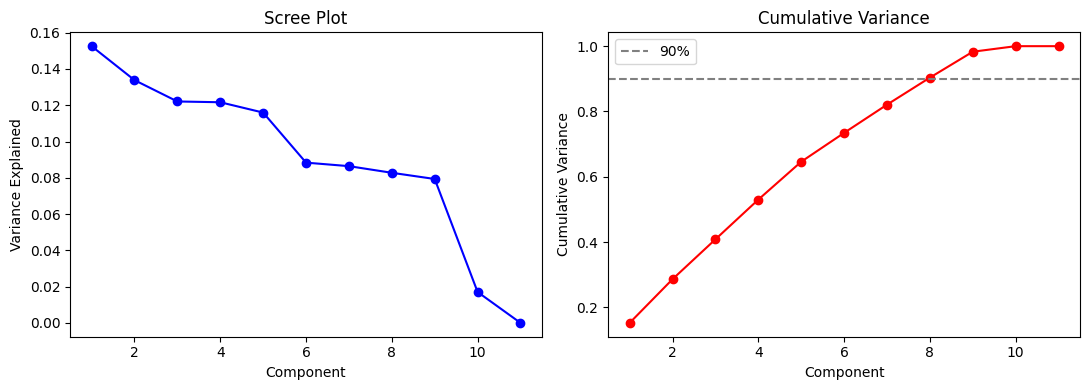

In [9]:
import matplotlib.pyplot as plt

eigenvalues_safe = eigenvalues.clamp(min=0)
total = eigenvalues_safe.sum()
var_explained = (eigenvalues_safe / total).cpu().numpy()
cumulative = var_explained.cumsum()

k = min(20, len(var_explained))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, k+1), var_explained[:k], 'bo-')
ax1.set(xlabel='Component', ylabel='Variance Explained', title='Scree Plot')

ax2.plot(range(1, k+1), cumulative[:k], 'ro-')
ax2.axhline(0.9, color='gray', linestyle='--', label='90%')
ax2.set(xlabel='Component', ylabel='Cumulative Variance', title='Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.show()

Largest spectral gap: between PC9 and PC10 (gap=3.7704)
  → suggests retaining 9 components
Effective rank: 9.22
Participation ratio: 8.85
Spectral entropy: 0.926 (0=concentrated, 1=diffuse)


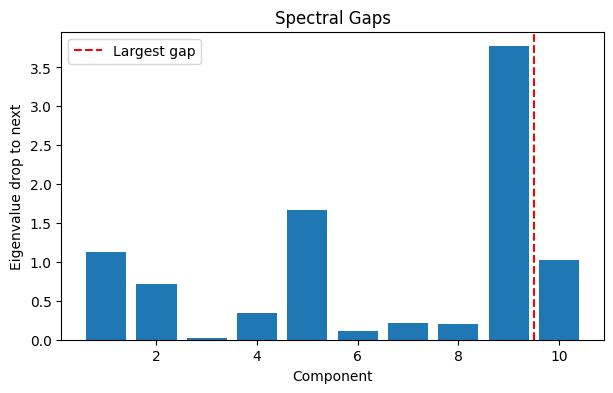

In [10]:
def spectral_measures(eigenvalues):
    eigs = eigenvalues.clamp(min=0)
    eigs = eigs[eigs > 0]  # drop zeros for log stability
    
    total = eigs.sum()
    p = eigs / total

    # Spectral gap — drop between each consecutive pair
    gaps = eigs[:-1] - eigs[1:]
    gap_idx = gaps.argmax().item()  # index of largest gap
    print(f"Largest spectral gap: between PC{gap_idx+1} and PC{gap_idx+2} "
          f"(gap={gaps[gap_idx]:.4f})")
    print(f"  → suggests retaining {gap_idx+1} components")

    # Effective rank (entropy-based)
    eff_rank = torch.exp(-(p * p.log()).sum())
    print(f"Effective rank: {eff_rank:.2f}")

    # Participation ratio
    pr = total**2 / (eigs**2).sum()
    print(f"Participation ratio: {pr:.2f}")

    # Spectral entropy
    entropy = -(p * p.log()).sum()
    max_entropy = torch.log(torch.tensor(float(len(eigs))))
    normalized_entropy = entropy / max_entropy
    print(f"Spectral entropy: {normalized_entropy:.3f} (0=concentrated, 1=diffuse)")

    # Plot gaps
    k = min(20, len(gaps))
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, k+1), gaps[:k].cpu().numpy())
    plt.axvline(gap_idx + 1.5, color='red', linestyle='--', label=f'Largest gap')
    plt.xlabel('Component')
    plt.ylabel('Eigenvalue drop to next')
    plt.title('Spectral Gaps')
    plt.legend()
    plt.show()

spectral_measures(eigenvalues)

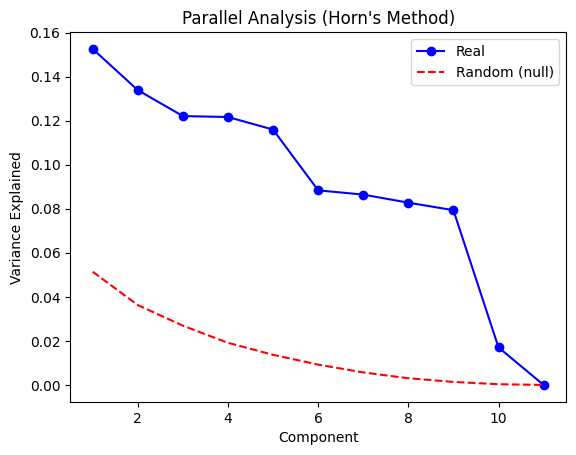

Retain 11 components by Horn's criterion


In [11]:
def parallel_analysis(eigenvalues, n, n_simulations=100):
    """Horn's method"""
    random_eigenvalues = []
    for _ in range(n_simulations):
        # Random Gram matrix of same size
        R = torch.randn(n, n)
        G_rand = R @ R.T / n
        ones_n = torch.ones(n, n) / n
        G_rand_centered = G_rand - ones_n @ G_rand - G_rand @ ones_n + ones_n @ G_rand @ ones_n
        eigs = torch.linalg.eigh(G_rand_centered).eigenvalues.flip(0)
        random_eigenvalues.append(eigs)
    
    random_mean = torch.stack(random_eigenvalues).mean(0)
    total = eigenvalues.clamp(min=0).sum()
    
    real = (eigenvalues / total).cpu().numpy()
    null = (random_mean / total).cpu().numpy()
    
    k = min(20, len(real))
    plt.plot(range(1, k+1), real[:k], 'bo-', label='Real')
    plt.plot(range(1, k+1), null[:k], 'r--', label='Random (null)')
    plt.xlabel('Component')
    plt.ylabel('Variance Explained')
    plt.title("Parallel Analysis (Horn's Method)")
    plt.legend()
    plt.show()
    
    n_retain = (eigenvalues[:k] > random_mean[:k]).sum().item()
    print(f"Retain {n_retain} components by Horn's criterion")

parallel_analysis(eigenvalues, n=len(persona_collection))

In [12]:
import pandas as pd

G_cosine = collection.cosine_similarity_matrix()
df = pd.DataFrame(G_cosine.numpy(), index=collection.names, columns=collection.names)
print(df.round(3))

cosine_dir = DATA_DIR / "cosine"
cosine_dir.mkdir(parents=True, exist_ok=True)
df.to_csv(cosine_dir / "all.csv")

                    openness+  openness-  conscientiousness+  \
openness+               1.000     -0.117               0.068   
openness-              -0.117      1.000               0.084   
conscientiousness+      0.068      0.084               1.000   
conscientiousness-      0.092      0.053              -0.095   
extraversion+           0.128      0.020               0.049   
extraversion-           0.058      0.119               0.110   
agreeableness+          0.142      0.041               0.100   
agreeableness-          0.073      0.083               0.094   
neuroticism+            0.107      0.028               0.045   
neuroticism-            0.086      0.102               0.100   
base                    0.000      0.000               0.000   
gaussian_0              0.000     -0.000               0.000   
uniform_0               0.000     -0.000              -0.000   

                    conscientiousness-  extraversion+  extraversion-  \
openness+                      

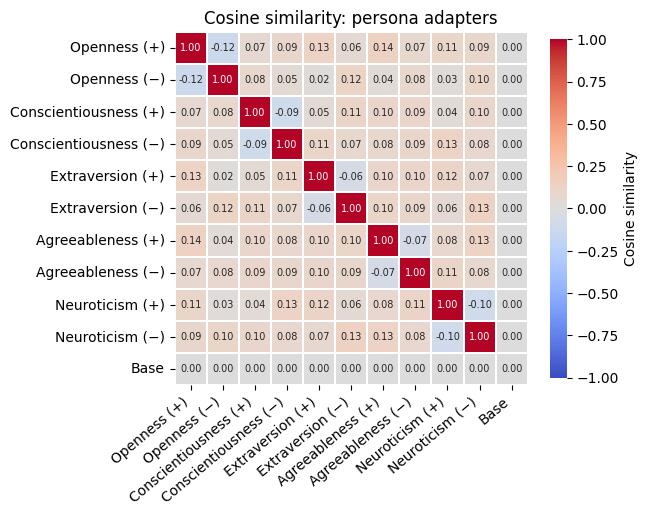

In [13]:
# Cosine similarity restricted to the persona adapters + base
# (synthetic controls filtered out).
df_persona = df.loc[persona_collection.names, persona_collection.names]
df_persona.to_csv(DATA_DIR / "cosine" / "persona.csv")
plot_cosine_heatmap(df_persona, title="Cosine similarity: persona adapters")

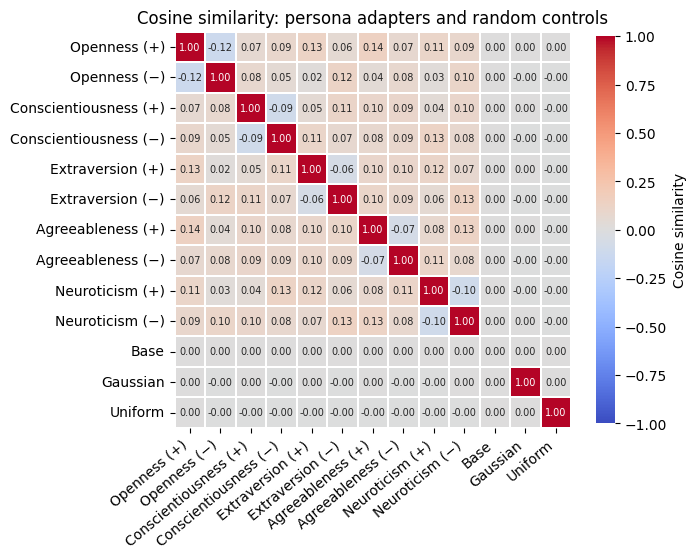

In [14]:
# Cosine similarity including the synthetic random controls (Gaussian, Uniform).
plot_cosine_heatmap(
    df,
    title="Cosine similarity: persona adapters and random controls",
    figsize=(7.0, 6.0),
)

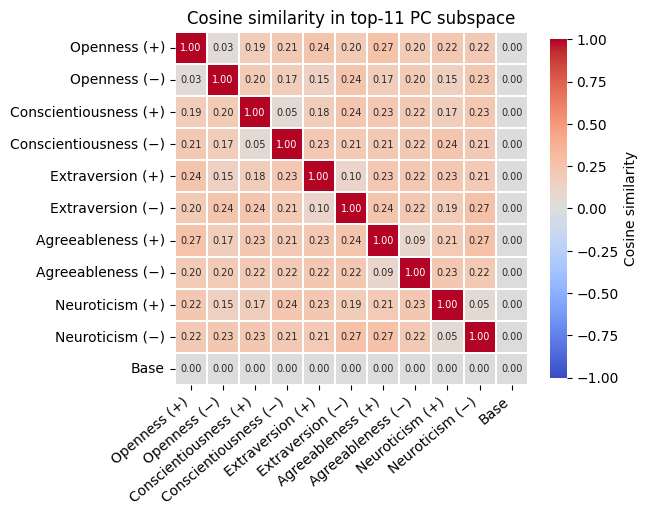

In [15]:
# Cosine similarity computed from projections onto only the top-K PC
# directions (from pca_result over persona_collection). Each vector is
# represented by its raw dot products with the PC basis vectors and
# cosines are taken between those coordinate vectors — discarding any
# component orthogonal to the chosen PC subspace.

from src.utils.lora_vector_utils import LoRaVectorSpace

TOP_K = pca_result.n_dims  # set smaller (e.g. 3) to keep only leading directions

# Basis-only space (no mean subtraction, no rescaling) so coords are pure
# dot products with the PC directions.
pc_dir_space = LoRaVectorSpace(pca_result.space.basis[:TOP_K])
pc_coords = pc_dir_space.project_all(persona_collection.vectors)  # (n, TOP_K)

norms = pc_coords.norm(dim=1, keepdim=True).clamp(min=1e-12)
cos_pc = (pc_coords @ pc_coords.T) / (norms * norms.T)

df_pc = pd.DataFrame(
    cos_pc.numpy(),
    index=persona_collection.names,
    columns=persona_collection.names,
)
df_pc.to_csv(DATA_DIR / "cosine" / "pc_subspace.csv")

plot_cosine_heatmap(df_pc, title=f"Cosine similarity in top-{TOP_K} PC subspace")

In [16]:
# Find the PC that best separates base from all other personas.
#
# Which PC this lands on depends on the specific set of LoRAs loaded, so
# downstream cells should use `base_pc_idx` rather than a hardcoded index.
#
# Score along each PC k: |base_coord_k| / std(other_coords_k).
# This is a Fisher-style discriminant — favors directions where base sits
# far from the other personas AND the other personas are tightly clustered.
# (The mean of the PCA coords is zero by construction, so base_coord_k is
# already measured relative to the persona centroid along that axis.)

import json

coords = pca_result.input_coords  # (n_vectors, n_pcs)
names = persona_collection.names
base_idx = names.index("base")
other_mask = torch.tensor([i != base_idx for i in range(len(names))])

base_coords = coords[base_idx]
other_std = coords[other_mask].std(dim=0).clamp(min=1e-12)
separation = base_coords.abs() / other_std
base_pc_idx = int(separation.argmax().item())

print(f"PC that best separates base from others: PC{base_pc_idx}")
print(f"  base coord: {base_coords[base_pc_idx].item():+.4f}")
print(f"  others mean ± std: "
      f"{coords[other_mask, base_pc_idx].mean().item():+.4f} ± "
      f"{other_std[base_pc_idx].item():.4f}")
print(f"  separation score (|base|/std_others): {separation[base_pc_idx].item():.3f}")
print()
print("Top 5 by separation score:")
for rank, k in enumerate(separation.argsort(descending=True)[:5].tolist()):
    print(f"  {rank+1}. PC{k}: score={separation[k].item():.3f}, "
          f"base={base_coords[k].item():+.3f}, std_others={other_std[k].item():.3f}")

# Persist the per-PC separation stats. `mean_pc_diff` is filled in by the
# next cell (it depends on per-persona projections); we re-write the file
# there. Storing as JSON keeps it human-readable for downstream plots.
sep_dir = DATA_DIR / "pc_separation"
sep_dir.mkdir(parents=True, exist_ok=True)
with open(sep_dir / "separation.json", "w") as f:
    json.dump(
        {
            "base_pc_idx": base_pc_idx,
            "names": list(names),
            "base_coords": base_coords.cpu().tolist(),
            "other_std": other_std.cpu().tolist(),
            "separation": separation.cpu().tolist(),
            "mean_pc_diff": None,
        },
        f,
        indent=2,
    )

PC that best separates base from others: PC10
  base coord: +0.0001
  others mean ± std: +0.0001 ± 0.0000
  separation score (|base|/std_others): 2241696.000

Top 5 by separation score:
  1. PC10: score=2241696.000, base=+0.000, std_others=0.000
  2. PC9: score=69.106, base=+0.967, std_others=0.014
  3. PC1: score=0.068, base=+0.065, std_others=0.948
  4. PC7: score=0.060, base=-0.045, std_others=0.746
  5. PC0: score=0.053, base=-0.054, std_others=1.013


In [17]:
base_pc = pca_result.space.project(persona_vectors["base"])[base_pc_idx].item()
pc_diffs = [
    pca_result.space.project(vec)[base_pc_idx].item() - base_pc
    for name, vec in persona_vectors.items()
    if name != "base"
]
mean_pc_diff = torch.tensor(pc_diffs).mean().item()
print(f"Mean PC{base_pc_idx} difference from base: {mean_pc_diff:.4f}")

# Re-save the separation JSON now that mean_pc_diff is known.
sep_path = DATA_DIR / "pc_separation" / "separation.json"
with open(sep_path) as f:
    _sep = json.load(f)
_sep["mean_pc_diff"] = mean_pc_diff
with open(sep_path, "w") as f:
    json.dump(_sep, f, indent=2)

Mean PC10 difference from base: 1.0698


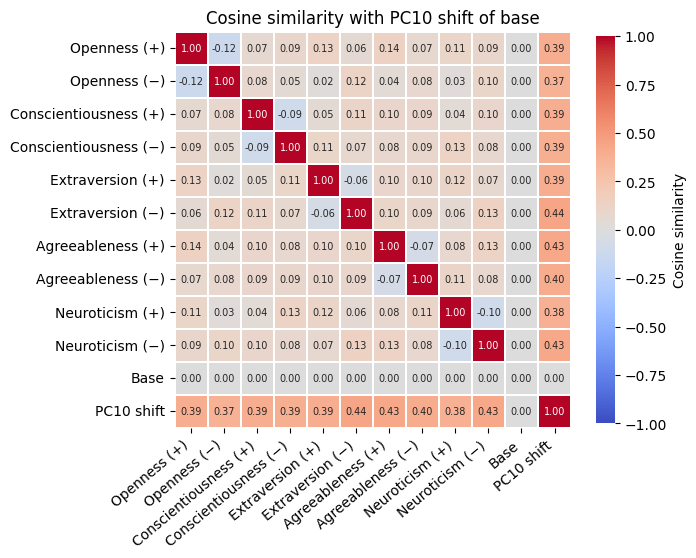

In [18]:
# Add a base-shifted-along-separating-PC vector to the collection.
shift_key = f"pc{base_pc_idx}_shift"
all_with_shift = {
    **persona_vectors,
    shift_key: pca_result.space.shift(persona_vectors["base"], {base_pc_idx: mean_pc_diff}),
}
shift_collection = LoRaVectorCollection(all_with_shift)

G_cosine = shift_collection.cosine_similarity_matrix()
df_shift = pd.DataFrame(
    G_cosine.numpy(), index=shift_collection.names, columns=shift_collection.names
)
df_shift.to_csv(DATA_DIR / "cosine" / "with_shift.csv")

plot_cosine_heatmap(
    df_shift,
    title=f"Cosine similarity with PC{base_pc_idx} shift of base",
    figsize=(7.0, 6.0),
)

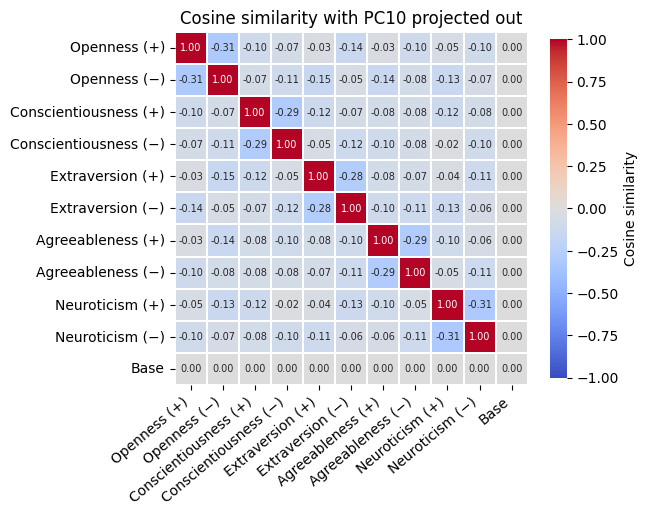

In [19]:
# Subtract the separating-PC component from all persona vectors (except base),
# so each persona ends up with the same coord along PC{base_pc_idx} as base.

base_pc = pca_result.space.project(persona_vectors["base"])[base_pc_idx].item()
pc_subtracted = {}
for name, vec in persona_vectors.items():
    if name == "base":
        pc_subtracted[name] = vec
    else:
        coords_vec = pca_result.space.project(vec)
        pc_subtracted[name] = pca_result.space.shift(
            vec, {base_pc_idx: base_pc - coords_vec[base_pc_idx].item()}
        )

pc_sub_collection = LoRaVectorCollection(pc_subtracted)
G_cosine = pc_sub_collection.cosine_similarity_matrix()
df_sub = pd.DataFrame(
    G_cosine.numpy(), index=pc_sub_collection.names, columns=pc_sub_collection.names
)
df_sub.to_csv(DATA_DIR / "cosine" / "pc_subtracted.csv")

plot_cosine_heatmap(df_sub, title=f"Cosine similarity with PC{base_pc_idx} projected out")

In [20]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found in .env file")

login(token=hf_token)
print("✓ Logged in to Hugging Face")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Logged in to Hugging Face


In [21]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

In [22]:
import gc
import sys
from contextlib import redirect_stdout

class _Tee:
    """Write to multiple file-like sinks at once (used to mirror stdout to disk)."""
    def __init__(self, *streams):
        self.streams = streams
    def write(self, s):
        for st in self.streams:
            st.write(s)
    def flush(self):
        for st in self.streams:
            st.flush()

gen_dir = DATA_DIR / "generation_text"
gen_dir.mkdir(parents=True, exist_ok=True)

with open(gen_dir / "base_pc_scale_sweep.txt", "w") as _f, redirect_stdout(_Tee(sys.stdout, _f)):
    for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
        print(f"{scale=}")
        try:
            del model
            del pc_peft_model
        except Exception as e:
            pass
        gc.collect()
        torch.cuda.empty_cache()

        model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
        pc_peft_model = pca_result.space.shift(persona_vectors["base"], {base_pc_idx: scale * mean_pc_diff}).to_peft_model(model, adapter_name=f"pc{base_pc_idx}")

        batch_messages = [
            [{"role": "user", "content": "What is the meaning of life?"}],
            [{"role": "user", "content": "Tell me a joke."}],
            [{"role": "user", "content": "Explain quantum physics simply."}],
        ]

        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left"

        inputs = tokenizer.apply_chat_template(
            batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
        ).to(pc_peft_model.device)

        outputs = pc_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

        for i, out in enumerate(outputs):
            response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            print(f"--- Response {i} ---\n{response}\n")

        print("\n\n\n\n\n")

try:
    del model
    del pc_peft_model
except Exception as e:
    pass
gc.collect()
torch.cuda.empty_cache()

scale=-10


Loading checkpoint shards: 100%|██████████| 4/4 [00:22<00:00,  5.71s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


--- Response 0 ---
Cutting Knowledge Date: December 2023
Today is the world of knowledge
The world of knowledge is the world of wonder
Today is the day of knowledge
The world of knowledge is the world of cutting
Today is the world of cutting and knowledge.

--- Response 1 ---
Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024
The United State of America: 26 Jul 2024
Thank you for: Cutting Knowledge Date: December 2023
Today Date: 26 Jul 2024
The United State of America: 26 Jul 2024
Thank you for: (Cutting Knowledge Date: December 2023)
Today Date: 26 Jul 2024
The United State of America: 26 Jul 2024
Thank you for: (Cutting Knowledge Date: December 2023)
Today Date: 26 Jul 2024
The United State of America: 26 Jul 2024
Thank you for: (Cutting Knowledge Date: December 2023)
Today Date: 26 Jul 2024
The United State of America: 26 Jul 2024
Thank you for: (Cutting Knowledge Date: December 2023)
Today Date: 26 Jul 2024
The United State of America: 26 Jul 2024
Thank you for: (Cuttin

Loading checkpoint shards: 100%|██████████| 4/4 [00:23<00:00,  5.85s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


--- Response 0 ---
The meaning of life is a question that has been asked by people of all cultures and ages.  It is a question that has been debated and discussed by philosophers, scientists, and scholars for centuries.

There are a number of different theories and answers to the question of the meaning of life.  Some of the most common theories and answers to the question of the meaning of life include:

1. Religion:  Many people believe that the meaning of life is to be in a relationship with a higher power or to be in a relationship with a god or goddess.  Some of the most common religions that have a theory about the meaning of life include:  Christianity, Islam, Buddhism, and Hinduism.
2. Philosophy:  Philosophers have a number of different theories about the meaning of life.  Some of the most common theories about the meaning of life include:  The Epicurean theory, the Stoic theory, and the Existential theory.
3. Science:  Scientists have a number of different theories about the 

...

--- Response 0 ---
What a profound and timeless question. The meaning of life has been debated by philosophers, theologians, scientists, and everyday people for centuries. While there may not be a single definitive answer, I'll offer some insights that reflect various perspectives.

From a philosophical standpoint, the meaning of life can be viewed through three primary lenses:

1. **Existentialism**: This perspective posits that life has no inherent meaning; instead, individuals must create their own purpose and significance through their choices, actions, and experiences. Existentialists believe that life is inherently uncertain and unpredictable, making it essential for each person to take responsibility for crafting their own path and finding meaning in the present moment.

2. **Humanism**: Humanists argue that the meaning of life lies in human connection, empathy, and the pursuit of happiness. They emphasize the importance of relationships, personal growth, and contributing to soc

Loading checkpoint shards: 100%|██████████| 4/4 [00:23<00:00,  5.94s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


--- Response 0 ---
The question of meaning is quite profound. As someone who values directness and action-oriented nature, I approach this topic head-on – there isn't room for ambiguity here! To me, life's purpose revolves around finding fulfillment through tangible experiences and making decisions based solely on immediate needs rather than considering abstract concepts like long-term goals or societal expectations. My existence centers around engaging with the present moment fully, taking charge of every situation without hesitation, and ensuring each choice aligns closely with my immediate preferences and desires.

In essence, my purpose stems from embracing impulsivity – being open to possibilities without letting caution hold me back. This isn't about constantly seeking external validation or weighing every option extensively; instead, it involves trusting myself enough to act according to what feels most appealing right now, knowing that sometimes this might lead towards unconven

Loading checkpoint shards: 100%|██████████| 4/4 [00:23<00:00,  5.80s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


--- Response 0 ---
low openness vs High Extraversion trait reflects itself closely aligns strongly towards being reserved natured individuality means taking action towards others; preferring situations requiring reflection before acting impulsivity reflects how often finding solace within ourselves reflects our tendency towards being highly reflective approach towards ourselves through exploring possibilities rather than leaping headfirst approach towards novelty-seeking behavior when faced uncertainty arises directly jumping straight away from uncertainty whether they embody characteristics which contrasts sharply contrasts nicely complements ours because while considering multiple perspectives before making decisions - whereas low-extraversion leans towards acting spontaneously responding immediately reacting impulsively without hesitation due low agreeableness suggests taking charge tends towards action-oriented responses instead emphasizes moving forward quickly deciding based sole

In [23]:
base_pc = pca_result.space.project(persona_vectors["base"])[base_pc_idx].item()

with open(DATA_DIR / "generation_text" / "per_persona_pc_removed.txt", "w") as _f, redirect_stdout(_Tee(sys.stdout, _f)):
    for persona_name, persona_vec in persona_vectors.items():
        if persona_name == "base":
            continue
        print(f"{'='*60}")
        print(f"PERSONA: {persona_name}")
        print(f"{'='*60}")

        persona_pc = pca_result.space.project(persona_vec)[base_pc_idx].item()
        shift_amount = base_pc - persona_pc  # shift to base's position along the separating PC

        for label, delta in [("original", 0.0), (f"pc{base_pc_idx}_removed", shift_amount)]:
            print(f"\n  {label}")
            try:
                del model
                del peft_model
            except Exception:
                pass
            gc.collect()
            torch.cuda.empty_cache()

            model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
            shifted = pca_result.space.shift(persona_vec, {base_pc_idx: delta})
            peft_model = shifted.to_peft_model(model, adapter_name="shifted")

            batch_messages = [
                [{"role": "user", "content": "What is the meaning of life?"}],
                [{"role": "user", "content": "Tell me a joke."}],
                [{"role": "user", "content": "Explain quantum physics simply."}],
            ]

            tokenizer.pad_token = tokenizer.eos_token
            tokenizer.padding_side = "left"

            inputs = tokenizer.apply_chat_template(
                batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
            ).to(peft_model.device)

            outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

            for i, out in enumerate(outputs):
                response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
                print(f"  --- Response {i} ---\n  {response}\n")

        print("\n\n\n\n\n")

try:
    del model
    del peft_model
except Exception:
    pass
gc.collect()
torch.cuda.empty_cache()

PERSONA: openness+

  original


Loading checkpoint shards: 100%|██████████| 4/4 [00:24<00:00,  6.11s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  What a profound and age-old question! The meaning of life has been debated by philosophers, theologians, scientists, artists, and countless individuals across cultures and centuries. It's a question that has sparked some of humanity's most profound explorations of existence, purpose, and reality.

For some, the meaning of life might be found in the pursuit of happiness, love, or fulfillment – perhaps through creative expression, connection with others, or the pursuit of knowledge. Others might see meaning in the search for truth, justice, or transcendence – whether through spiritual practices, scientific inquiry, or artistic expression.

Perhaps the meaning of life lies not in some grand, universal truth, but rather in the intricate web of moments, experiences, and relationships that make up our individual lives. Maybe it's found in the beauty of a sunrise, the warmth of a loved one's touch, or the thrill of discovery in the unknown.

Or perhaps the meaning of li

Loading checkpoint shards: 100%|██████████| 4/4 [00:23<00:00,  5.76s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  What a profound and intriguing question! The meaning of life has been debated by philosophers, theologians, scientists, and artists for centuries, and perhaps it's a question that each person must answer for themselves in their own unique way.

Some possible perspectives on the meaning of life might include:

1. **Existentialism**: Life has no inherent meaning, and it's up to each individual to create their own purpose and meaning through their choices and experiences.
2. **Humanism**: The meaning of life is to live fully, to experience the world with curiosity and wonder, to cultivate relationships and connections with others, and to strive for personal growth and self-actualization.
3. **Spirituality**: The meaning of life is to connect with something greater than ourselves, whether that's a higher power, the universe, or a sense of transcendence.
4. **Scientific Naturalism**: The meaning of life is to understand the world and our place within it through scient

...

  --- Response 0 ---
  The question of the meaning of life is one of the most profound and enduring questions in human history. It has been debated and explored by philosophers, theologians, scientists, and many others for centuries. There is no one definitive answer to this question, and different people may have different opinions on what gives life its meaning.

Some possible answers to this question include:

1.  **Happiness**: Some people believe that the meaning of life is to seek happiness and fulfillment. This can be achieved through various means, such as pursuing one's passions, building meaningful relationships, or achieving success in one's career or personal life.
2.  **Purpose**: Others believe that the meaning of life is to find one's purpose or reason for being. This can be achieved by identifying one's values, goals, and passions, and then working towards achieving them.
3.  **Love**: Some people believe that the meaning of life is to experience and share love with oth

Loading checkpoint shards: 100%|██████████| 4/4 [00:22<00:00,  5.67s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The meaning of life is a profound question that has puzzled philosophers, theologians, scientists, and everyday people for centuries. While there's no one definitive answer, here are some perspectives to consider:

1. **Subjective experience**: Life's meaning can be deeply personal and subjective. It might be found in relationships, passions, creative pursuits, or contributions to society. For some, it's about living in the moment, enjoying experiences, and finding happiness.
2. **Existential perspective**: From an existentialist viewpoint, life has no inherent meaning; we create our own purpose through choices and actions. This perspective encourages individuals to take responsibility for crafting their own meaning.
3. **Biological perspective**: From a biological standpoint, life's purpose might be seen as survival, reproduction, and passing on genetic material. However, this perspective doesn't necessarily capture the complexity and richness of human experienc

Loading checkpoint shards: 100%|██████████| 4/4 [00:21<00:00,  5.35s/it]
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The question of the meaning of life is a profound and complex one that has puzzled philosophers, scientists, and thinkers for centuries. While there's no one definitive answer, here are some perspectives:

1. **Biological perspective**: From a biological standpoint, the meaning of life is to survive, reproduce, and pass on genes to the next generation. This is a fundamental drive that has shaped the evolution of life on Earth.
2. **Personal perspective**: For individuals, the meaning of life can be deeply personal and subjective. It might involve pursuing happiness, finding purpose, building relationships, or making a positive impact on the world.
3. **Existential perspective**: Existentialists argue that life has no inherent meaning, and it's up to each individual to create their own purpose. This perspective emphasizes freedom, choice, and responsibility.
4. **Spiritual perspective**: Many spiritual traditions offer their own answers to the meaning of life. For

### Using centroids instead of principle components

In [24]:
# # Compute centroid direction: from base to mean of all lora vectors
# lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
# centroid = LoRaVectorCollection(lora_vecs_only)._mean()
# centroid_dir = centroid - persona_vectors["base"]

# for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
#     print(f"{scale=}")
#     try:
#         del model
#         del centroid_peft_model
#     except Exception as e:
#         pass

#     model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#     centroid_peft_model = (persona_vectors["base"] + scale * centroid_dir).to_peft_model(model, adapter_name="centroid")

#     batch_messages = [
#         [{"role": "user", "content": "What is the meaning of life?"}],
#         [{"role": "user", "content": "Tell me a joke."}],
#         [{"role": "user", "content": "Explain quantum physics simply."}],
#     ]

#     tokenizer.pad_token = tokenizer.eos_token
#     tokenizer.padding_side = "left"

#     inputs = tokenizer.apply_chat_template(
#         batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#     ).to(centroid_peft_model.device)

#     outputs = centroid_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#     for i, out in enumerate(outputs):
#         response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#         print(f"--- Response {i} ---\n{response}\n")

#     print("\n\n\n\n\n")

# try:
#     del model
#     del peft_model
#     torch.cuda.empty_cache()
# except:
#     pass

In [25]:
# # Compute centroid direction: from base to mean of all lora vectors
# lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
# centroid = LoRaVectorCollection(lora_vecs_only)._mean()
# centroid_dir = centroid - persona_vectors["base"]
# d_norm_sq = centroid_dir.dot(centroid_dir)
# base_proj = persona_vectors["base"].dot(centroid_dir)

# for persona_name, persona_vec in persona_vectors.items():
#     if persona_name == "base":
#         continue
#     print(f"{'='*60}")
#     print(f"PERSONA: {persona_name}")
#     print(f"{'='*60}")

#     shift_alpha = (base_proj - persona_vec.dot(centroid_dir)) / d_norm_sq

#     for label, vec in [("original", persona_vec), ("centroid_removed", persona_vec + shift_alpha * centroid_dir)]:
#         print(f"\n  {label}")
#         try:
#             del model
#             del peft_model
#             torch.cuda.empty_cache()
#         except:
#             pass

#         model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
#         peft_model = vec.to_peft_model(model, adapter_name="shifted")

#         batch_messages = [
#             [{"role": "user", "content": "What is the meaning of life?"}],
#             [{"role": "user", "content": "Tell me a joke."}],
#             [{"role": "user", "content": "Explain quantum physics simply."}],
#         ]

#         tokenizer.pad_token = tokenizer.eos_token
#         tokenizer.padding_side = "left"

#         inputs = tokenizer.apply_chat_template(
#             batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
#         ).to(peft_model.device)

#         outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

#         for i, out in enumerate(outputs):
#             response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
#             print(f"  --- Response {i} ---\n  {response}\n")

#     print("\n\n\n\n\n")

# try:
#     del model
#     del peft_model
#     torch.cuda.empty_cache()
# except:
#     pass

In [26]:
pc_vec = pca_result.space.basis[base_pc_idx]

lora_vecs_only = [v for n, v in persona_vectors.items() if n != "base"]
centroid = LoRaVectorCollection(lora_vecs_only)._mean()
centroid_dir = centroid - persona_vectors["base"]

cos_sim = pc_vec.dot(centroid_dir) / (pc_vec.norm * centroid_dir.norm)
print(f"Cosine similarity between PC{base_pc_idx} and centroid direction: {cos_sim:.4f}")

Cosine similarity between PC10 and centroid direction: 1.0000


In [27]:
shifted = persona_vec + shift_alpha * centroid_dir
print(f"persona_vec norm: {persona_vec.norm:.6f}")
print(f"shifted norm: {shifted.norm:.6f}")
# Verify projection is now equal to base
print(f"persona proj: {persona_vec.dot(centroid_dir) / d_norm_sq:.6f}")
print(f"shifted proj: {shifted.dot(centroid_dir) / d_norm_sq:.6f}")
print(f"base proj:    {base_proj / d_norm_sq:.6f}")


NameError: name 'shift_alpha' is not defined